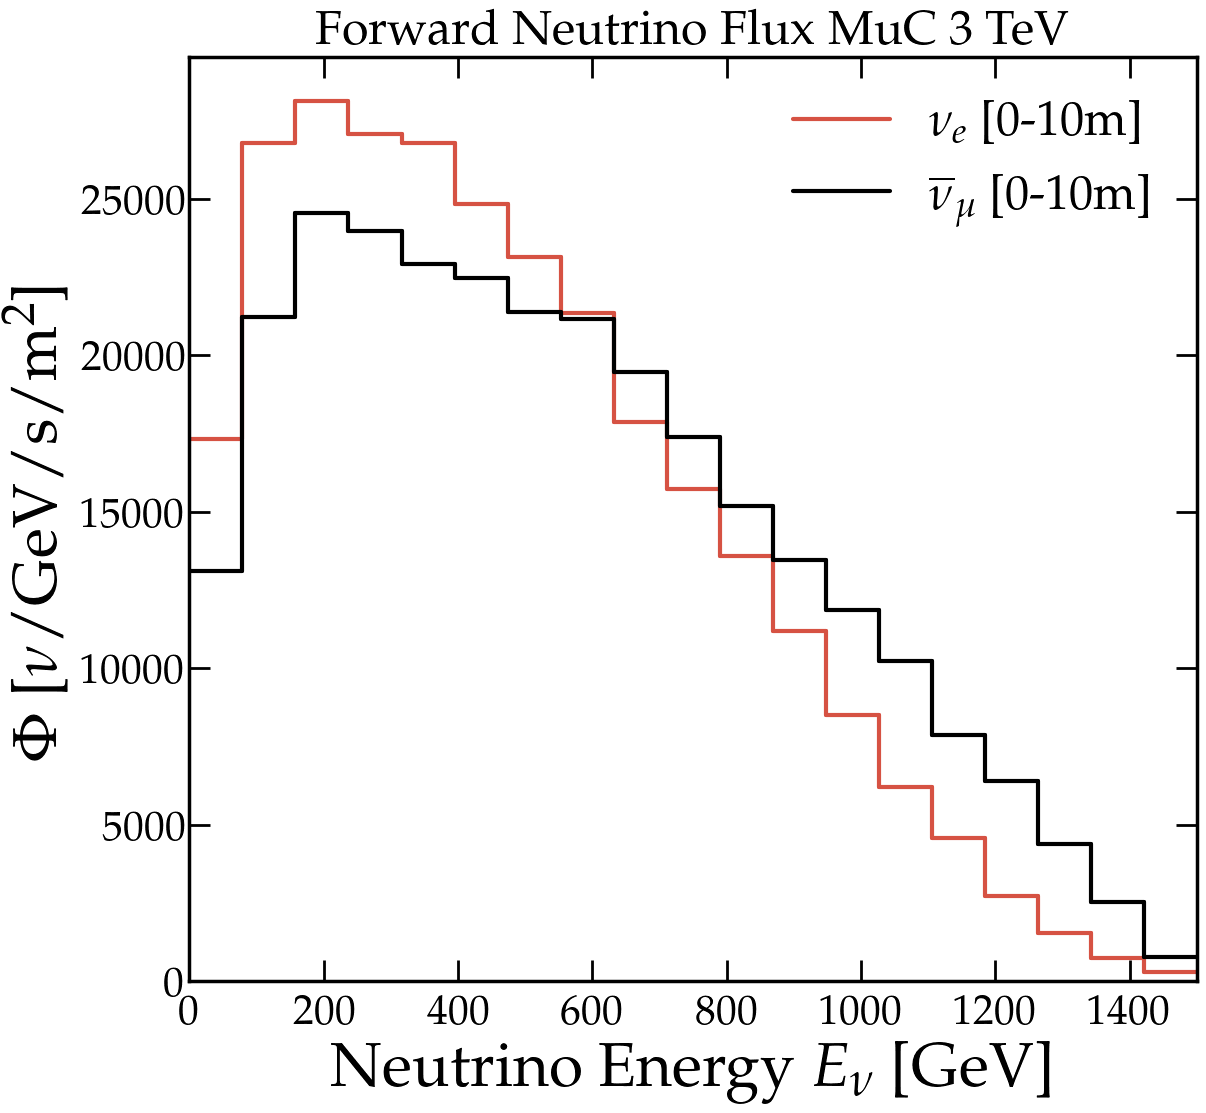

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.integrate import simpson

plt.style.use('../Analysis/sty.mplstyle')

####################################################################################################################
##################################### Function to Plot the Histograms ##############################################
####################################################################################################################
def PlotFluxes(ax, x, y, label=None, color='black'):
    width = x[1] - x[0]
    for i in range(len(x)):
        xi, yi = x[i], y[i]
        if i < len(x)-1:
            ax.plot([xi - width/2, xi + width/2], [yi, yi], color=color) # Plot Horizontal Line
            ax.plot([xi + width/2, xi + width/2], [yi, y[i+1]], color=color) # Plot Vertical Line
        else:
            ax.plot([xi - width/2, xi + width/2], [yi, yi], color=color, label=label) # Plot Horizontal Line

####################################################################################################################
#################################### Upload and Read the Data ######################################################
####################################################################################################################
digitized_ = np.loadtxt('Digitized_forward_neutrino_flux_muc_3tev.txt')

Energy = digitized_[:,0] # Neutrino Energy in GeV (Column 0)

nue_flux_0_to_10 = digitized_[:,1] # Flux in 1/GeV/s (Column 1)
#nue_flux_10_to_20 = digitized_[:,2] # Flux in 1/GeV/s (Column 2)
#nue_flux_20_to_30 = digitized_[:,3] # Flux in 1/GeV/s (Column 3)
#nue_flux_30_to_40 = digitized_[:,4] # Flux in 1/GeV/s (Column 4)
#nue_flux_40_to_50 = digitized_[:,5] # Flux in 1/GeV/s (Column 5)

antinumu_flux_0_to_10 = digitized_[:,6] # Flux in 1/GeV/s (Column 6)
#antinumu_flux_10_to_20 = digitized_[:,7] # Flux in 1/GeV/s (Column 7)
#antinumu_flux_20_to_30 = digitized_[:,8] # Flux in 1/GeV/s (Column 8)
#antinumu_flux_30_to_40 = digitized_[:,9] # Flux in 1/GeV/s (Column 9)
#antinumu_flux_40_to_50 = digitized_[:,10] # Flux in 1/GeV/s (Column 10)

####################################################################################################################
######################################### Writing to CSV ###########################################################
####################################################################################################################
Energy_csv = np.linspace(1500/38, 1500*37/38, 19)
Elow_csv = Energy_csv - 1500/38
Ehigh_csv = Energy_csv + 1500/38

nue_flux_0_to_10_csv = nue_flux_0_to_10/ ( np.pi*(10**2) ) # 1/GeV/s/m^2
#nue_flux_10_to_20_csv = nue_flux_10_to_20/ ( np.pi*(20**2 - 10**2) ) # 1/GeV/s/m^2
#nue_flux_20_to_30_csv = nue_flux_20_to_30/ ( np.pi*(30**2 - 20**2) ) # 1/GeV/s/m^2
#nue_flux_30_to_40_csv = nue_flux_30_to_40/ ( np.pi*(40**2 - 30**2) ) # 1/GeV/s/m^2
#nue_flux_40_to_50_csv = nue_flux_40_to_50/ ( np.pi*(50**2 - 40**2) ) # 1/GeV/s/m^2

total_nue_flux_0_to_10_csv = simpson(nue_flux_0_to_10_csv, Energy_csv)
nue_0_to_10_normProb = np.zeros_like(nue_flux_0_to_10_csv)
for i in range(len(nue_0_to_10_normProb)):
    bin_width = Ehigh_csv[i] - Elow_csv[i]
    nue_0_to_10_normProb[i] = nue_flux_0_to_10_csv[i]*bin_width/total_nue_flux_0_to_10_csv


antinumu_flux_0_to_10_csv = antinumu_flux_0_to_10/ ( np.pi*(10**2) ) # 1/GeV/s/m^2
#antinumu_flux_10_to_20_csv = antinumu_flux_10_to_20/ ( np.pi*(20**2 - 10**2) ) # 1/GeV/s/m^2
#antinumu_flux_20_to_30_csv = antinumu_flux_20_to_30/ ( np.pi*(30**2 - 20**2) ) # 1/GeV/s/m^2
#antinumu_flux_30_to_40_csv = antinumu_flux_30_to_40/ ( np.pi*(40**2 - 30**2) ) # 1/GeV/s/m^2
#antinumu_flux_40_to_50_csv = antinumu_flux_40_to_50/ ( np.pi*(50**2 - 40**2) ) # 1/GeV/s/m^2
total_antinumu_flux_0_to_10_csv = simpson(antinumu_flux_0_to_10_csv, Energy_csv)
antinumu_0_to_10_normProb = np.zeros_like(antinumu_flux_0_to_10_csv)
for i in range(len(antinumu_0_to_10_normProb)):
    bin_width = Ehigh_csv[i] - Elow_csv[i]
    antinumu_0_to_10_normProb[i] = antinumu_flux_0_to_10_csv[i]*bin_width/total_antinumu_flux_0_to_10_csv


with open("../csv/Fluxes/NormProb/nue_NormProb_0_to_10_MuC3TeV.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated Neutrino Flux: {total_nue_flux_0_to_10_csv} m^-2 s^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_csv, Ehigh_csv, nue_0_to_10_normProb)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

with open("../csv/Fluxes/NormProb/antinumu_NormProb_0_to_10_MuC3TeV.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated Antineutrino Flux: {total_antinumu_flux_0_to_10_csv} m^-2 s^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_csv, Ehigh_csv, antinumu_0_to_10_normProb)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

####################################################################################################################
####################################### Plotting the Fluxes ########################################################
####################################################################################################################
fig = plt.figure()
ax = fig.add_subplot()

#PlotFluxes(ax, Energy_csv, antinumu_flux_0_to_10, label='a', color='#d65243')
#PlotFluxes(ax, Energy_csv, antinumu_flux_10_to_20, label='a', color='#f8b599')
#PlotFluxes(ax, Energy_csv, antinumu_flux_20_to_30, label='a', color='#d0daeb')
#PlotFluxes(ax, Energy_csv, antinumu_flux_30_to_40, label='a', color='#84a7fc')
#PlotFluxes(ax, Energy_csv, antinumu_flux_40_to_50, label='a', color='#3a4cc0')

PlotFluxes(ax, Energy_csv, nue_flux_0_to_10_csv, label=r'$\nu_e$ [0-10m]', color='#d65243')
PlotFluxes(ax, Energy_csv, antinumu_flux_0_to_10_csv, label=r'$\overline{\nu}_\mu$ [0-10m]', color='k')
ax.legend()

ax.set_title(r'Forward Neutrino Flux MuC 3 TeV')
ax.set_ylabel(r'$\Phi$ [$\nu$/GeV/s/m$^2$]')
ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

ax.set_xlim(left=0, right=1500)
ax.set_ylim(bottom=0)

plt.savefig('../Plots/Figures_PDF/MuC3TeV_Flux.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/MuC3TeV_Flux.png', transparent=False, bbox_inches='tight')